# Week 3 시계열 데이터 과제

- **이론:** 정규 세션 핵심 내용 기반 주관식 2문제
- **실습:** ARIMA 모델 모델 활용 및 분석
<br><br> 모르는 부분 혹은 문제에 오류가 있는 경우 **24기_이용선** 으로 편하게 연락주세요:)

## 이론
- 정규세션의 핵심 내용을 기반으로 하여 출제한 주관식 문제입니다.

Q1. 시계열 데이터에서 정상성이 중요한 이유와 ARIMA 모델이 데이터의 비정상성을 처리하는 방법을 서술하시오.

A1. 시계열 모델은 과거의 패턴을 기반으로 미래 값을 예측하기 때문에 시간이 지나도 평균, 분산, 자기상관 구조가 일정한 정상성을 갖는 데이터에서 더 안정적으로 학습된다. 비정상 시계열에서는 평균이나 추세가 변하기 때문에 모델이 패턴을 제대로 학습하기 어렵다.

ARIMA 모델은 이러한 문제를 해결하기 위해 차분을 사용한다. 원 시계열에 차분을 적용하여 추세나 비정상성을 제거하고 정상 시계열로 변환한 뒤, 자기회귀와 이동평균 구조를 이용해 모델링을 수행한다.

Q2. 어떤 시계열의 특성이 다음과 같다. 해당 시계열의 **정상성 여부를 판단하고, 적절한 모형을 제시하시오.**
- 원 시계열 ACF는 매우 천천히 감소
- PACF는 1시차에서 큰 값 이후 점진적으로 감소
- 1차 차분 후 ACF는 절단 형태를 보임
- 차분 후 PACF는 점진적으로 감소
- 분산은 시간에 따라 변하지 않음

A2. 원 시계열의 ACF가 매우 천천히 감소하는 것은 비정상 시계열의 특징으로 볼 수 있으며, 추세가 존재할 가능성이 있다. 따라서 정상성을 확보하기 위해 1차 차분이 필요하다.
차분 후 ACF가 절단 형태를 보이고 PACF가 점진적으로 감소하는 것은 MA 구조의 특징이므로, 차분된 시계열에 대해 MA 모형을 적용하는 것이 적절하다.
따라서 이 시계열에는 ARIMA(0,1,1) 모형이 적절한 후보 모델로 판단된다.

## 실습: ARIMA  
- **ARIMA** 모델 실습입니다. 사용하는 데이터는 [kaggle의 2차 세계대전 날씨 데이터](https://www.kaggle.com/datasets/smid80/weatherww2)로, 아래 코드를 통해 간단하게 불러올 수 있습니다.
- 주어진 데이터를 활용하여 코드 중간중간 주어진 문제에 답해주세요.

### 데이터 전처리

In [23]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("smid80/weatherww2")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\smid80\weatherww2\versions\1


In [24]:
# kaggle 기본 제공 코드
import os

path = "C:/Users/user/.cache/kagglehub/datasets/smid80/weatherww2/versions/1"

print(os.listdir(path))

['Summary of Weather.csv', 'Weather Station Locations.csv']


In [25]:
# station별 위치 정보 데이터(위도, 경도 등)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

loc_file_path = os.path.join(path, "Weather Station Locations.csv")
loc_df = pd.read_csv(loc_file_path)
# 필요한 열들만 불러옴
loc_df = loc_df.loc[:, ["WBAN", "NAME", "STATE/COUNTRY ID", "Latitude", "Longitude"]]


loc_df.head()

,WBAN,NAME,STATE/COUNTRY ID,Latitude,Longitude
0,33013,AIN EL,AL,36.383333,6.650000
1,33031,LA SENIA,AL,35.616667,0.583333
2,33023,MAISON BLANCHE,AL,36.716667,3.216667
3,33044,TELERGMA,AL,36.116667,6.416667
4,12001,TINDOUF,AL,27.683333,-8.083333


In [26]:
# station별 실제 날씨 데이터
weather_file_path = os.path.join(path, "Summary of Weather.csv")
weather_df = pd.read_csv(weather_file_path)

# 필요한 열들만 불러옴
weather_df = weather_df.loc[:, ["STA", "Date", "MaxTemp", "MinTemp", "MeanTemp", "Precip"]]

# 데이터 정제: "T", 비가 측정할 수 없을 정도로 미미하게 옴을 의미함
# "T"로 인해 나머지 수치형 데이터가 범주형으로 취급받고 있으므로 "T" 수치형 값으로 변환함
weather_df["Precip"] = weather_df["Precip"].replace("T", 0.1)
# 숫자로 변환 (문자 → float)
weather_df["Precip"] = pd.to_numeric(weather_df["Precip"], errors="coerce")


weather_df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_12588\329226695.py:3: DtypeWarning: Columns (0: Snowfall, 1: PoorWeather, 2: SNF, 3: TSHDSBRSGF) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv(weather_file_path)


,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
0,10001,1942-7-1,25.555556,22.222222,23.888889,1.016
1,10001,1942-7-2,28.888889,21.666667,25.555556,0.000
2,10001,1942-7-3,26.111111,22.222222,24.444444,2.540
3,10001,1942-7-4,26.666667,22.222222,24.444444,2.540
4,10001,1942-7-5,26.666667,21.666667,24.444444,0.000


### 데이터 준비
- ARIMA는 자기 자신의 과거 값만으로 예측하는 모델이기 때문에 시간 순서와 예측할 하나의 값(예: 기온, 강수량)만을 필요로 합니다.
- 이번 실습에서는 **AGRA** 지역의 **강수량**를 대상으로 진행해보겠습니다.

In [27]:
# weather_df에는 지역 이름 없이 STA라는 관측소 ID만 존재하기 때문에, loc_df에서 지역의 관측소 ID를 찾음
loc_sta = loc_df[loc_df["NAME"] == "AGRA"].WBAN.iloc[0]
weather_bin = weather_df[weather_df.STA == int(loc_sta)]
weather_bin["Date"] = pd.to_datetime(weather_bin["Date"])
weather_bin

,STA,Date,MaxTemp,MinTemp,MeanTemp,Precip
70653,32701,1942-08-24,32.222222,25.000000,28.888889,0.000
70654,32701,1942-08-25,31.111111,25.555556,28.333333,9.652
70655,32701,1942-08-26,32.222222,25.000000,28.888889,0.762
70656,32701,1942-08-27,32.222222,24.444444,28.333333,19.558
70657,32701,1942-08-28,31.666667,25.555556,28.888889,2.540
...,...,...,...,...,...,...
71873,32701,1945-12-27,21.666667,4.444444,13.333333,0.000
71874,32701,1945-12-28,20.555556,4.444444,12.222222,0.000
71875,32701,1945-12-29,20.555556,4.444444,12.222222,0.000
71876,32701,1945-12-30,20.555556,3.888889,12.222222,0.000


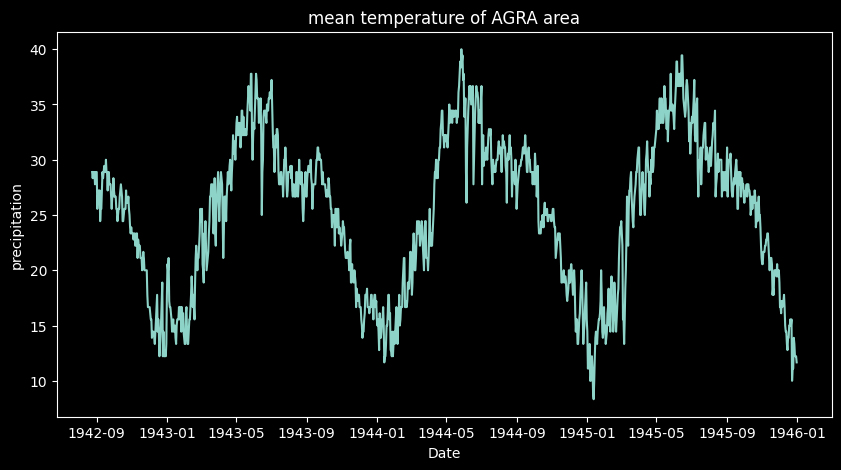

In [28]:
# 해당 지역의 평균 온도
plt.figure(figsize=(10, 5))
plt.plot(weather_bin.Date, weather_bin.MeanTemp)
plt.title("mean temperature of AGRA area")
plt.xlabel("Date")
plt.ylabel("precipitation")
plt.show()

In [29]:
timeSeries = weather_bin.loc[:, ["Date", "MeanTemp"]]
timeSeries.index = timeSeries.Date
ts = timeSeries.drop("Date", axis=1)
ts

,MeanTemp
Date,
1942-08-24,28.888889
1942-08-25,28.333333
1942-08-26,28.888889
1942-08-27,28.333333
1942-08-28,28.888889
...,...
1945-12-27,13.333333
1945-12-28,12.222222
1945-12-29,12.222222


<Figure size 640x480 with 0 Axes>

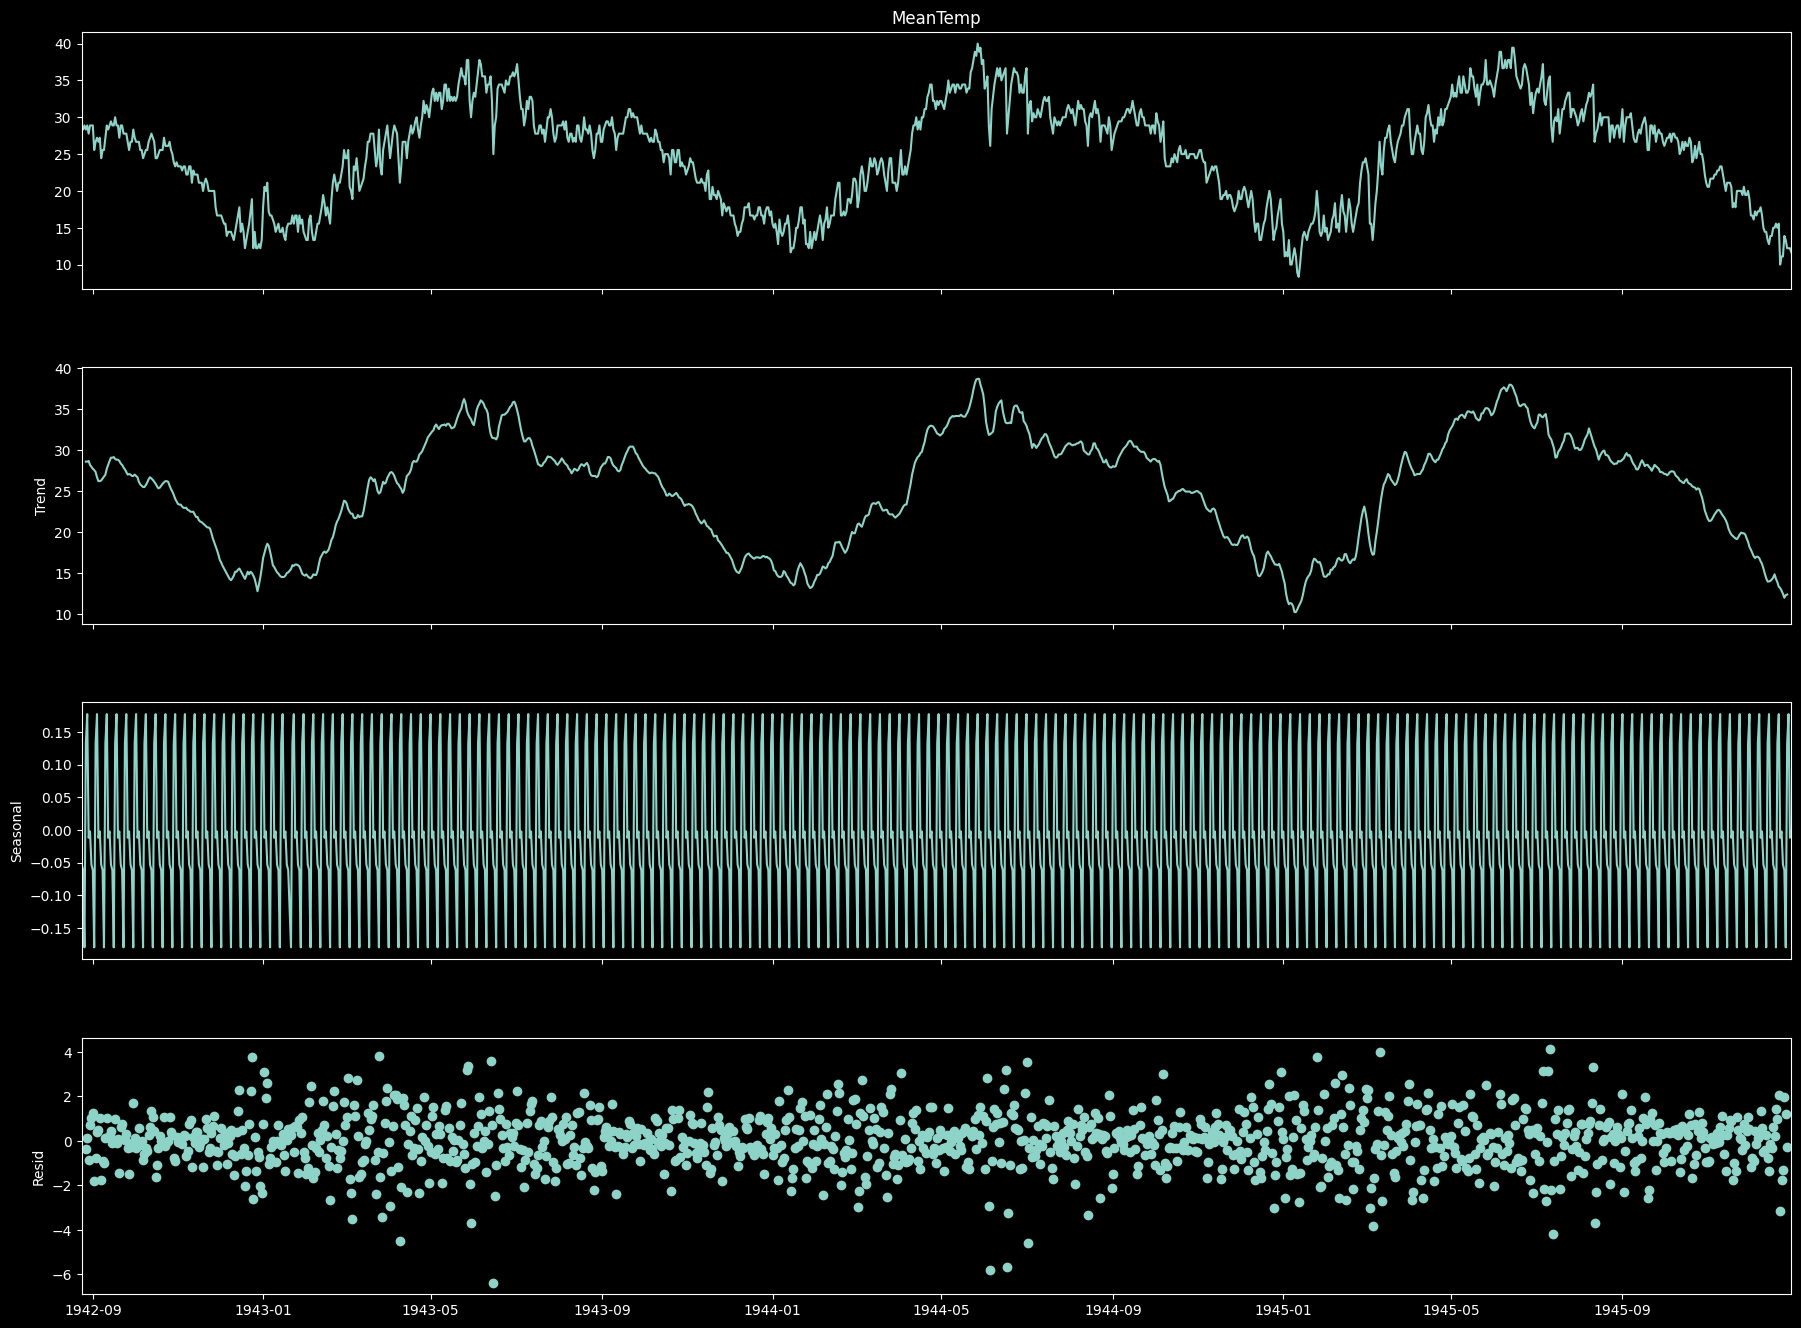

In [30]:
from statsmodels.tsa.seasonal import seasonal_decompose

# 시계열 구성요소별 분리
result = seasonal_decompose(ts["MeanTemp"], model='additive', period=7)

fig = plt.figure()
fig = result.plot()
fig.set_size_inches(20, 15)

### 정상성

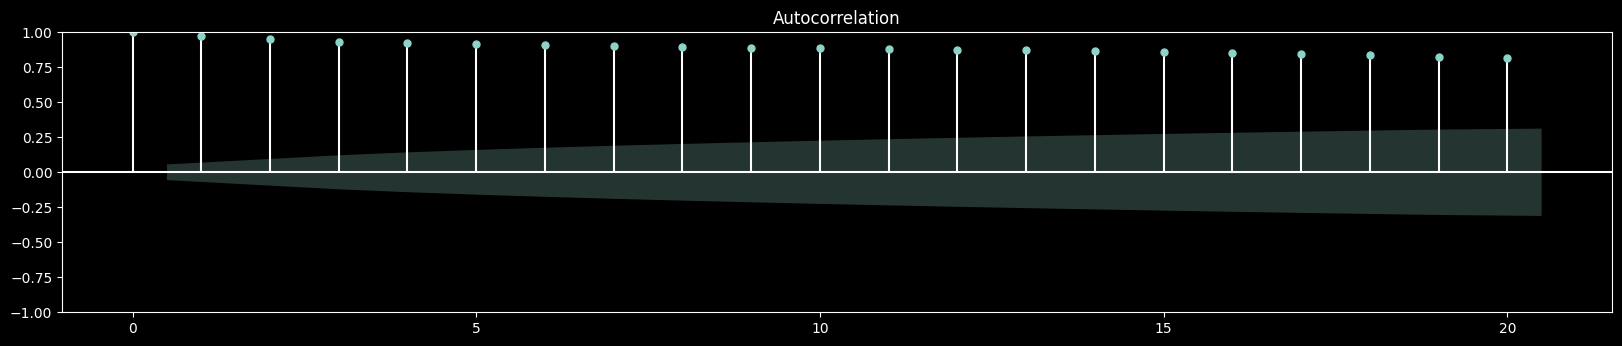

In [31]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)

In [32]:
from statsmodels.tsa.stattools import adfuller
result = adfuller(ts)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -2.062436
p-value: 0.259885
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q1. 위 결과를 통해 알 수 있는 것은 무엇인지, 대립가설과 귀무가설이라는 키워드를 사용하여 서술하세요.

A1. ACF 그래프에서 여러 시차(lag)에 걸쳐 자기상관 값이 매우 높게 유지되고 있으며 천천히 감소하는 모습을 보인다. 이는 시계열 데이터에 추세가 존재하거나 정상성이 만족되지 않을 가능성을 의미한다.

시계열 정상성 검정에서 귀무가설은 “해당 시계열은 단위근을 가지며 비정상 시계열이다”이고, 대립가설은 “시계열은 정상성을 가진다”이다.

그래프에서 자기상관이 오랫동안 높은 값을 유지하는 패턴은 단위근이 존재하는 비정상 시계열에서 흔히 나타나는 특징이므로, 이 결과는 귀무가설을 기각하기 어렵고 해당 시계열이 비정상 시계열일 가능성이 높다는 것을 시사한다.

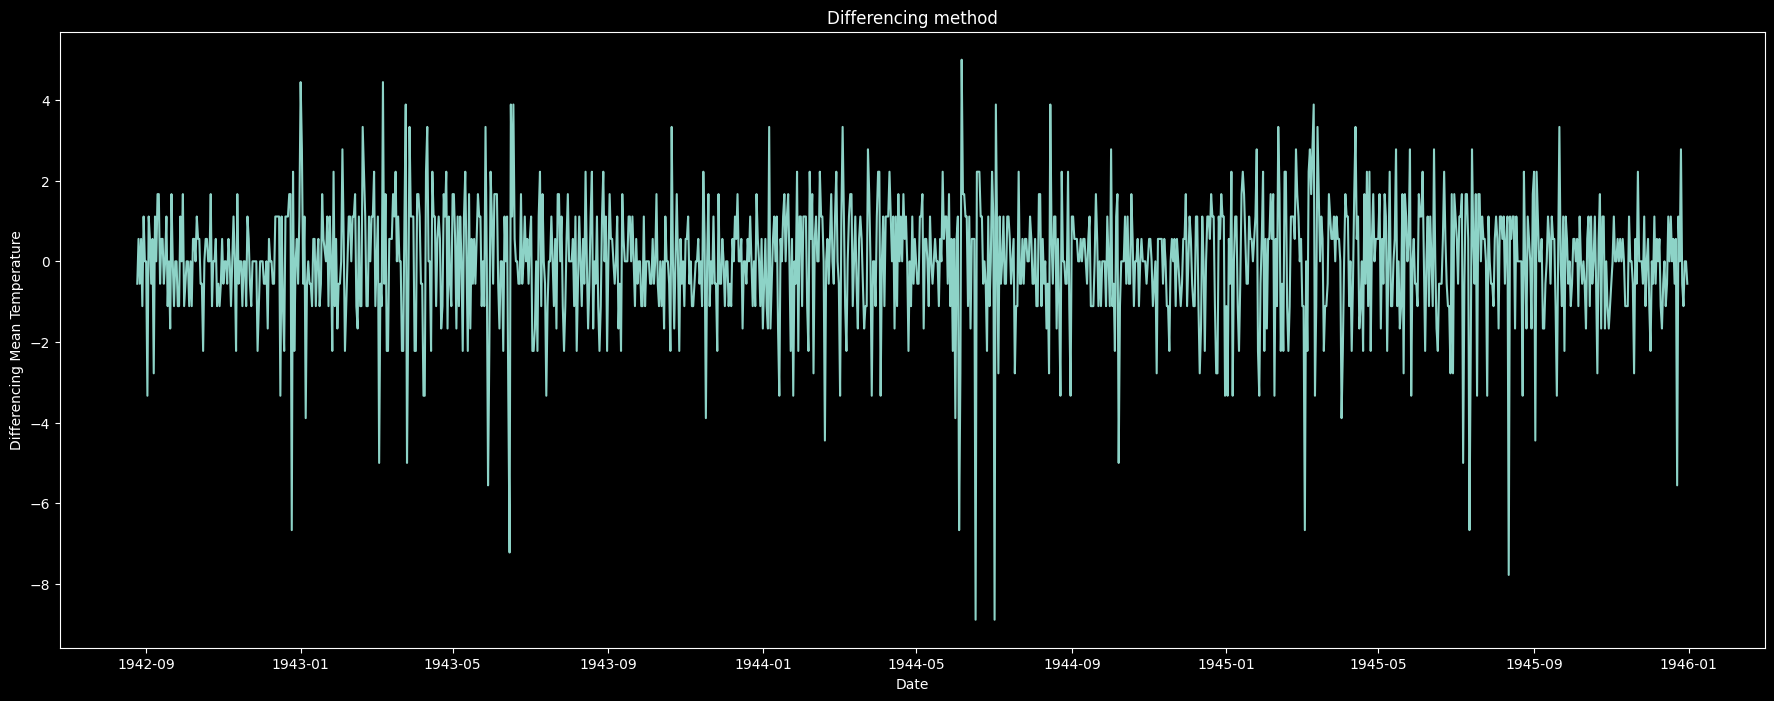

In [33]:
ts_diff = ts - ts.shift()
plt.figure(figsize=(22,8))
plt.plot(ts_diff)
plt.title("Differencing method")
plt.xlabel("Date")
plt.ylabel("Differencing Mean Temperature")
plt.show()

In [34]:
result = adfuller(ts_diff[1:])
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
    print('\t%s: %.3f' % (key, value))

ADF Statistic: -6.294669
p-value: 0.000000
Critical Values:
	1%: -3.436
	5%: -2.864
	10%: -2.568


Q2. 이전의 결과와 비교했을 때 무엇이 달라졌으며, 그 이유는 무엇인가요?

A2. 차분을 적용한 이후 시계열의 값들이 평균을 중심으로 비교적 일정하게 변동하며, 이전에 보이던 장기적인 추세가 제거된 것을 확인할 수 있다.

이는 차분 연산이 연속된 시점 간의 변화량을 계산하여 추세를 제거하는 역할을 하기 때문이다. 원래 시계열은 자기상관이 강하게 유지되는 비정상 데이터였지만, 차분을 통해 추세 성분이 제거되면서 평균과 분산이 일정한 정상 시계열에 가까운 형태로 변환된 것이다.

따라서 이전 결과와 비교했을 때 추세가 제거되어 데이터가 보다 안정적인 패턴을 보이게 되었으며 정상성이 개선된 것이 가장 큰 변화라고 볼 수 있다.

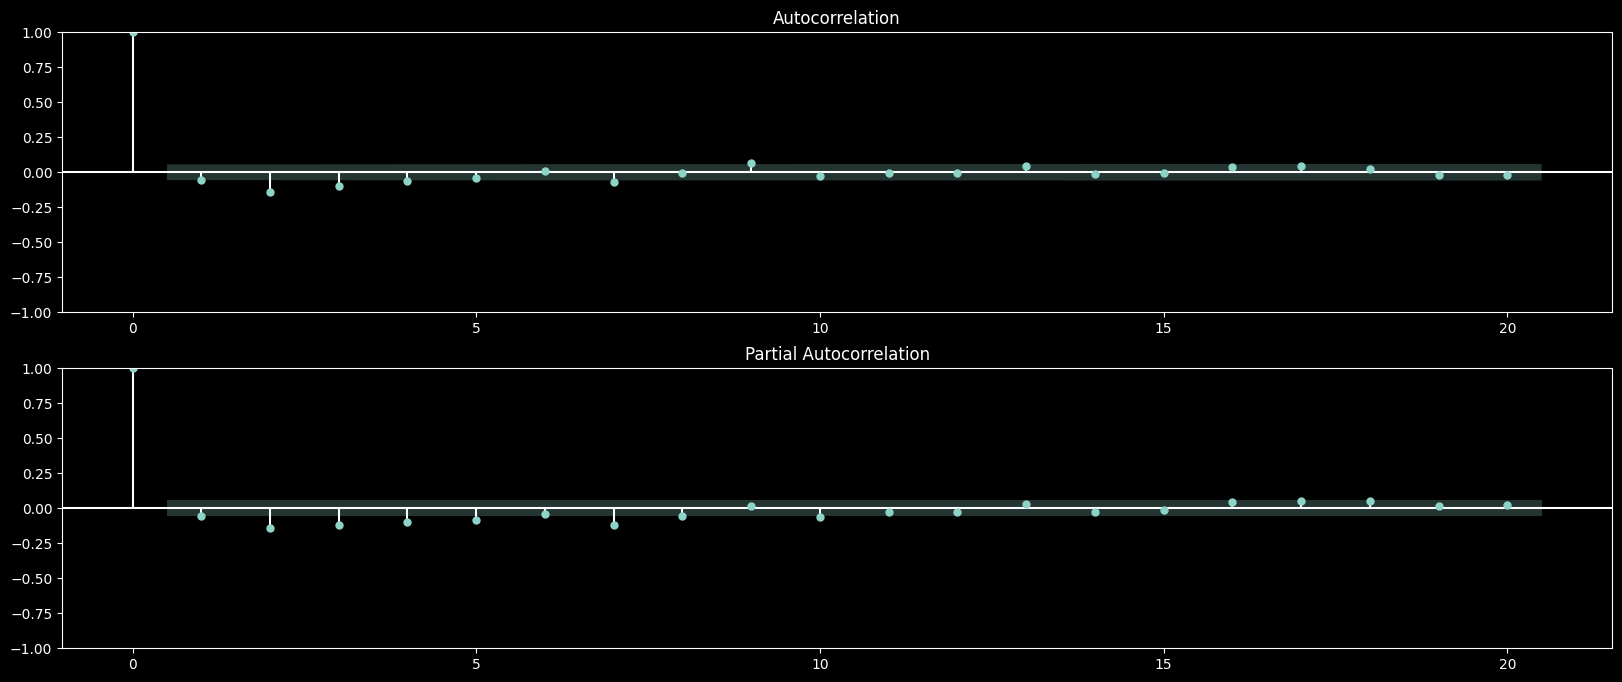

In [35]:
import statsmodels.api as sm

fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(ts_diff[1:], lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
fig = sm.graphics.tsa.plot_pacf(ts_diff[1:], lags=20, ax=ax2)

Q3. 두 그림이 의미하는 바가 무엇이며, 이를 통해 아래 ARIMA의 하이퍼파라미터인 p와 q를 얼마로 설정해야할지 그 숫자와 근거를 적어주세요. 이후 변수를 선언해주세요.

A3. 위 그래프는 차분된 시계열(ts_diff)에 대한 ACF와 PACF를 나타낸 것이다.
ACF 그래프에서는 1시차 이후 대부분의 값이 신뢰구간 안에 위치하며 빠르게 0에 가까워지는 모습을 보인다. 이는 MA 성분이 크게 존재하지 않음을 의미한다.

PACF 그래프 역시 특정 시차에서 뚜렷하게 절단되는 패턴 없이 대부분 신뢰구간 내에 존재한다. 이는 자기회귀 성분 또한 강하게 나타나지 않는다는 것을 의미한다.

즉, 차분 이후의 시계열은 이미 정상성을 가지며 추가적인 AR 또는 MA 구조가 크게 필요하지 않은 형태로 해석할 수 있다. 따라서 ARIMA 모형에서 AR(p)와 MA(q)의 차수는 각각 0으로 설정하는 것이 적절하다고 판단된다.

차분을 이미 한 번 수행했으므로 d=1이 되고, 최종적으로 적절한 모형은 ARIMA(0,1,0) 이 된다.

### ARIMA

C:\Users\user\OneDrive\Desktop\힘\투빅스\정규세션 과제\PythonProject\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\OneDrive\Desktop\힘\투빅스\정규세션 과제\PythonProject\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\OneDrive\Desktop\힘\투빅스\정규세션 과제\PythonProject\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


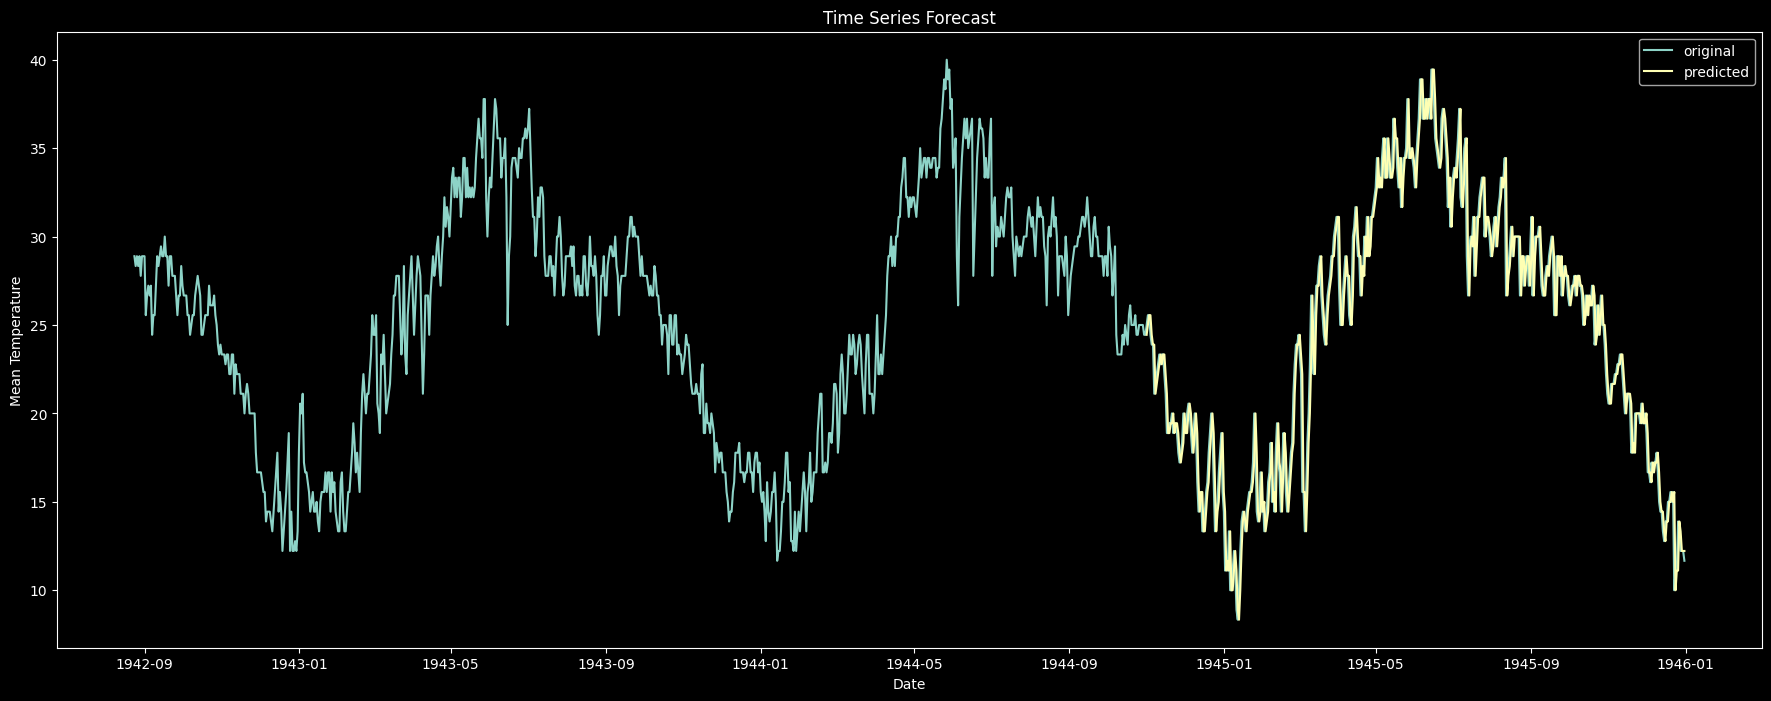

In [36]:
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime

## fit_this_code
p = 0
d = 1
q = 0

# fit model
model = ARIMA(ts, order=(p,d,q))
model_fit = model.fit()

# predict
start_index = datetime(1944, 11, 1)
end_index = datetime(1945, 12, 31)
forecast = model_fit.predict(start=start_index, end=end_index, typ='levels')

# visualization
plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date, weather_bin.MeanTemp, label="original")
plt.plot(forecast, label="predicted")
plt.title("Time Series Forecast")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.legend()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_12588\1273724452.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


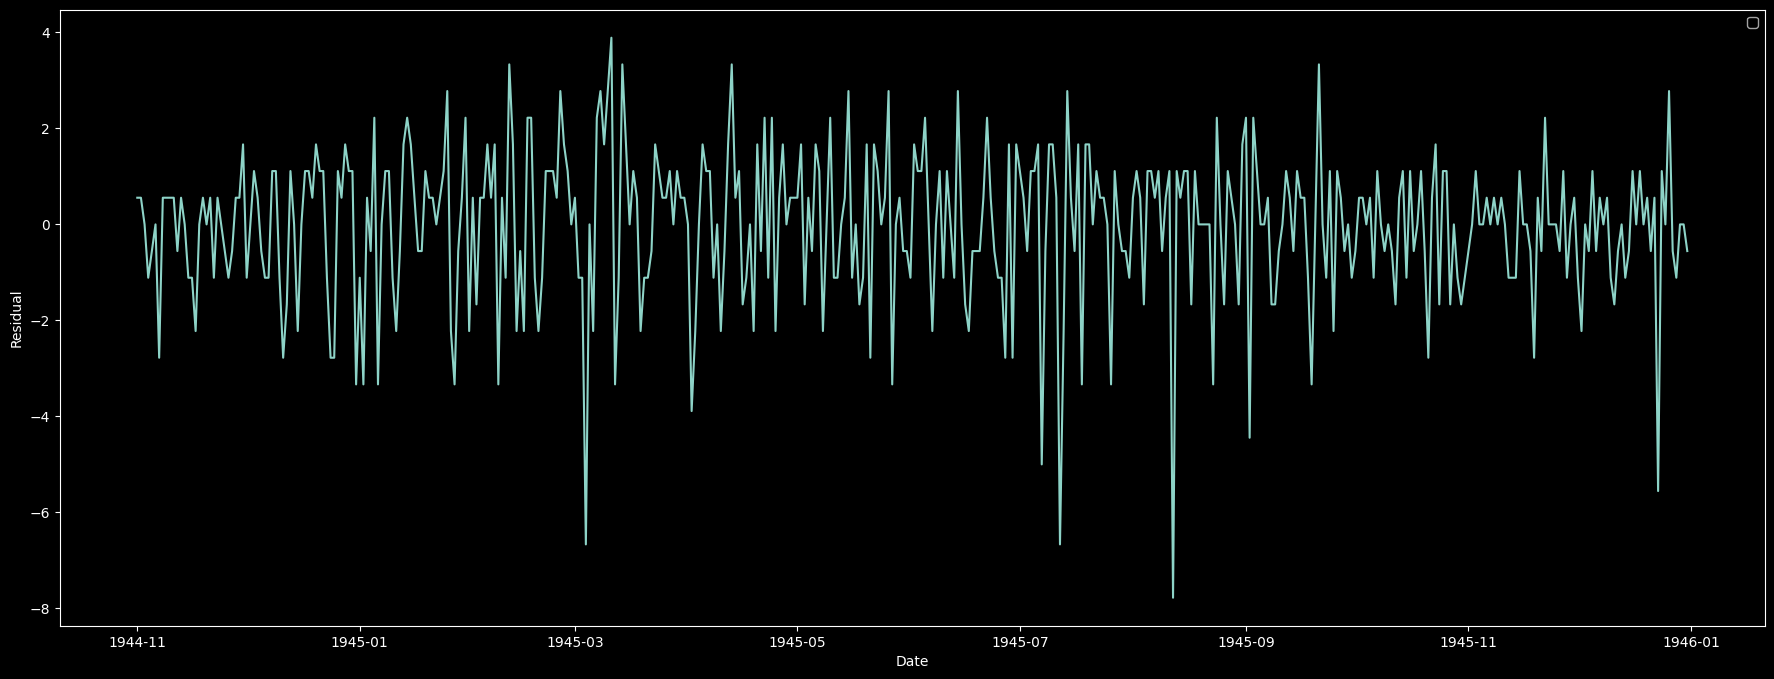

In [37]:
# 잔차 분석
resi = np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp) - np.array(forecast)

plt.figure(figsize=(22,8))
plt.plot(weather_bin.Date[weather_bin.Date >= start_index], resi)
plt.xlabel("Date")
plt.ylabel("Residual")
plt.legend()
plt.show()

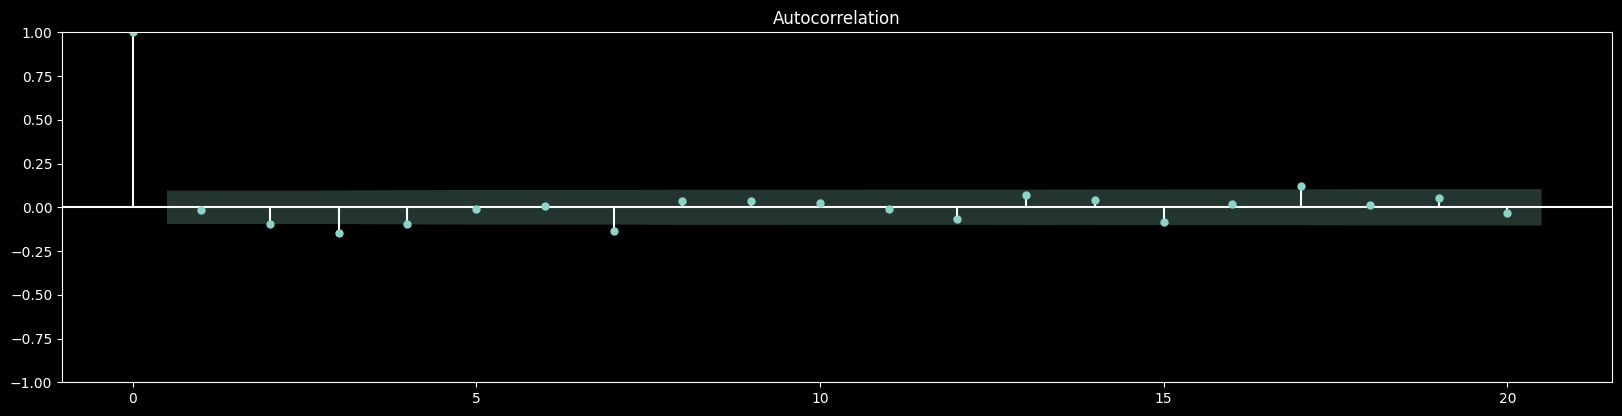

In [38]:
fig = plt.figure(figsize=(20,10))
ax1 = fig.add_subplot(211)
fig = sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)

In [39]:
result = adfuller(resi)
print('ADF Statistic: %f' % result[0])
print('p-value: %f' % result[1])
print('Critical Values:')
for key, value in result[4].items():
  print('\t%s: %.3f' % (key, value))

ADF Statistic: -11.375983
p-value: 0.000000
Critical Values:
	1%: -3.446
	5%: -2.868
	10%: -2.570


In [40]:
from sklearn import metrics

def scoring(y_true, y_pred):
  r2 = round(metrics.r2_score(y_true, y_pred) * 100, 3)
  # mae = round(metrics.mean_absolute_error(y_true, y_pred), 3)
  corr = round(np.corrcoef(y_true, y_pred)[0, 1], 3)
  mape = round(
    metrics.mean_absolute_percentage_error(y_true, y_pred) * 100, 3
  )
  rmse = round(
    np.sqrt(metrics.mean_squared_error(y_true, y_pred)), 3
  )

  df = pd.DataFrame({
    "R2": r2,
    "Corr": corr,
    "RMSE": rmse,
    "MAPE": mape
  }, index=[0])

  return df

In [41]:
scoring(np.array(weather_bin[weather_bin.Date >= start_index].MeanTemp), np.array(forecast))

,R2,Corr,RMSE,MAPE
0,95.56,0.978,1.565,5.366


Q4. 해당 결과가 의미하는 바가 무엇인지 서술하시오.

A4. ARIMA(0,1,0) 모형을 적용한 결과를 보면, 먼저 예측 그래프에서 모델이 전체적인 온도 변화 패턴을 비교적 잘 따라가는 것을 확인할 수 있다. 특히 시계열의 상승과 하락 흐름을 크게 벗어나지 않고 예측하고 있어 기본적인 추세는 적절히 반영된 것으로 보인다.

잔차 그래프를 보면 잔차들이 0을 중심으로 불규칙하게 분포하고 있으며 뚜렷한 추세나 패턴이 나타나지 않는다. 이는 모델이 시계열 데이터의 구조적인 패턴을 대부분 설명하고, 남은 값들은 랜덤한 오차에 가까운 형태임을 의미한다.

잔차의 ACF 그래프를 보면 대부분의 자기상관 값이 신뢰구간 안에 위치하고 있다. 이는 잔차들 사이에 유의미한 자기상관이 거의 없다는 것을 의미하며, 잔차가 잡음에 가까운 특성을 가진다는 것을 시사한다.

따라서 ARIMA(0,1,0) 모델은 이 시계열 데이터의 주요 패턴을 비교적 잘 설명하고 있으며, 잔차에서도 추가적인 자기상관 구조가 크게 나타나지 않아 모형이 적절하게 설정되었을 가능성이 높다고 해석할 수 있다.

## 추가실습

- AGRA 지역의 강수량 분석과는 별도로, 도시와 분석 요인을 자율적으로 선정하여 동일한 분석 과정을 수행하세요.
- 원활한 진행을 위해 데이터가 충분히 확보된 도시 리스트를 제공합니다.
- 코드 실행 후, 각 분석 과정에 대해 주석 또는 마크다운 텍스트로 자유롭게 설명하세요.
- 또한, 실습 1의 분석 결과와 비교하여 새롭게 도출된 인사이트를 구체적으로 서술하시기 바랍니다.

In [42]:
# 도시 리스트
merged = weather_df.merge(
    loc_df[["WBAN", "NAME"]],
    left_on="STA",
    right_on="WBAN"
)

counts = merged.groupby("NAME").size()

counts[counts >= 800]

NAME
ACCRA                1157
AGRA                 1225
AMBERLY               848
AMURI/FIELD AAF       884
ATAR                  876
                     ... 
TINDOUF               818
VAL DE CANS          1188
WALLER/BWI           1631
WHEELER/AFB 810.1    2192
WILLEMSTAD           1218
Length: 64, dtype: int64

In [45]:
#ACCRA 지역 온도 분석

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.arima.model import ARIMA

# Kaggle weather dataset 불러오기
weather_df = pd.read_csv("Summary of Weather.csv")
loc_df = pd.read_csv("Weather Station Locations.csv")

C:\Users\user\AppData\Local\Temp\ipykernel_12588\426824981.py:10: DtypeWarning: Columns (0: Snowfall, 1: PoorWeather, 2: SNF, 3: TSHDSBRSGF) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv("Summary of Weather.csv")


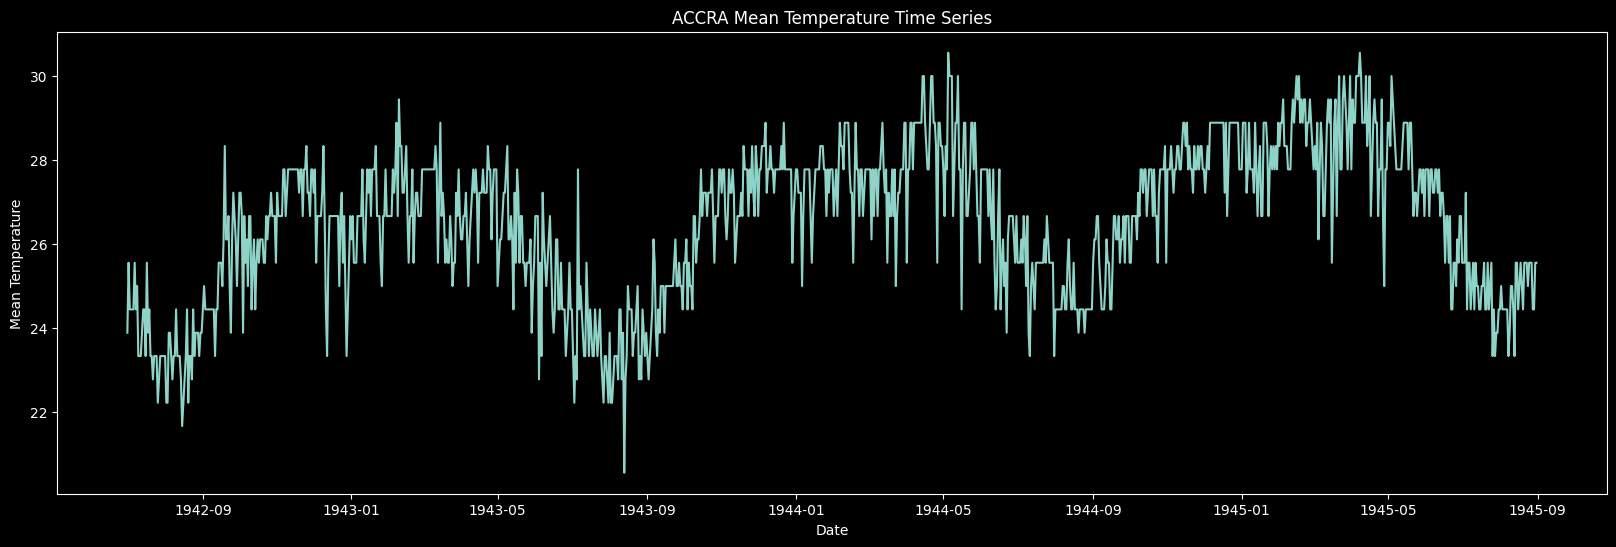

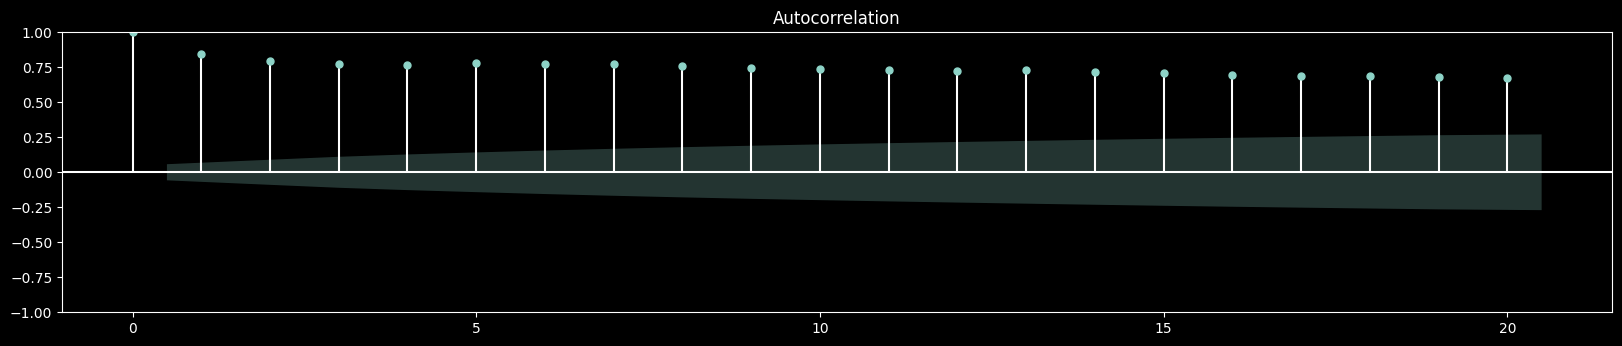

In [51]:
#데이터 준비
city = "ACCRA"

loc_sta = loc_df.loc[loc_df["NAME"] == city, "WBAN"].iloc[0]

city_weather = weather_df[weather_df.STA == loc_sta].copy()

city_weather["Date"] = pd.to_datetime(city_weather["Date"])
city_weather = city_weather.sort_values("Date")

#시계열 생성
ts = city_weather.set_index("Date")["MeanTemp"]
ts = ts.dropna()

plt.figure(figsize=(20,6))
plt.plot(ts)
plt.title(f"{city} Mean Temperature Time Series")
plt.xlabel("Date")
plt.ylabel("Mean Temperature")
plt.show()

#ACF 확인
fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
sm.graphics.tsa.plot_acf(ts, lags=20, ax=ax1)
plt.show()

Accra 지역의 평균 온도 시계열을 확인한 결과 전체적으로 일정한 범위 내에서 변동하지만, 시간에 따라 일정한 패턴을 가지며 완전히 안정적인 평균을 중심으로 움직이지 않는 모습을 보인다.

ACF 그래프에서는 lag가 증가하더라도 자기상관 값이 천천히 감소하는 형태가 나타난다.

이는 다음과 같은 의미를 가진다.
1. 시계열이 과거 값의 영향을 강하게 받음
2. 자기상관이 장기간 유지됨
3. 비정상 시계열일 가능성이 높음

통계적 가설 관점에서 보면

귀무가설(H0) : 시계열은 정상성을 가진다.

대립가설(H1) : 시계열은 정상성을 가지지 않는다.

ACF가 매우 천천히 감소하는 패턴을 보이므로 귀무가설을 기각하고 해당 시계열은 비정상 시계열로 판단할 수 있다.

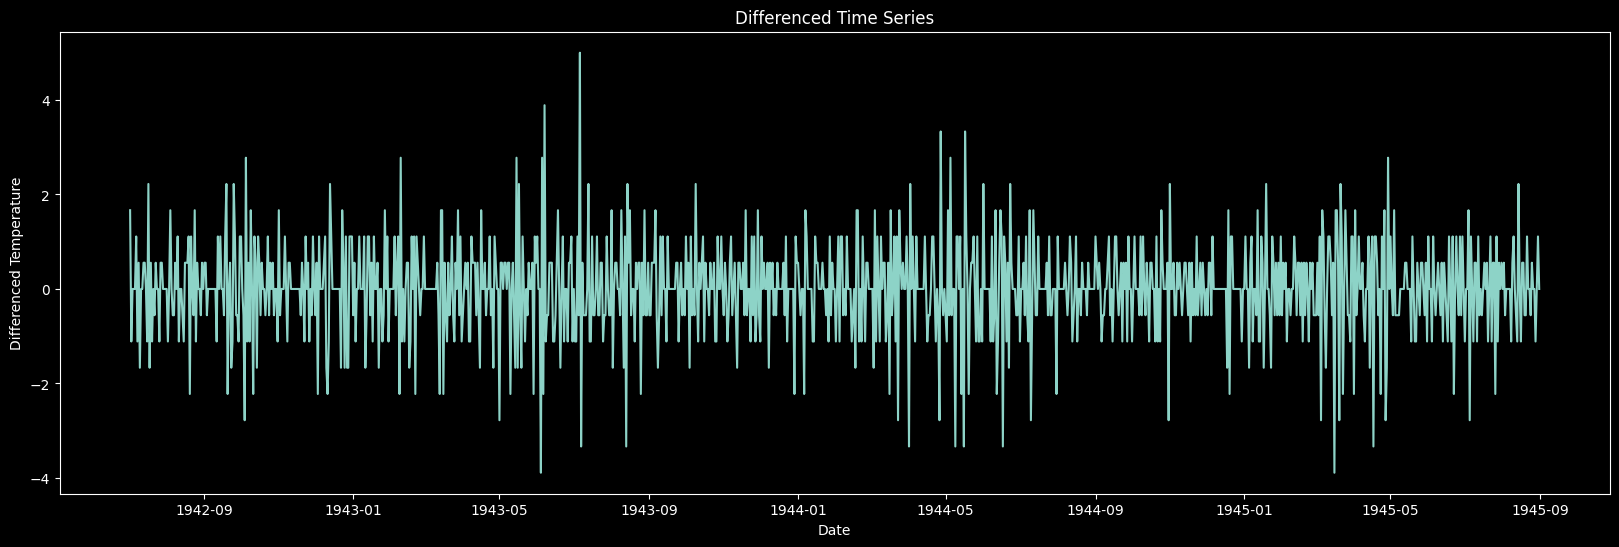

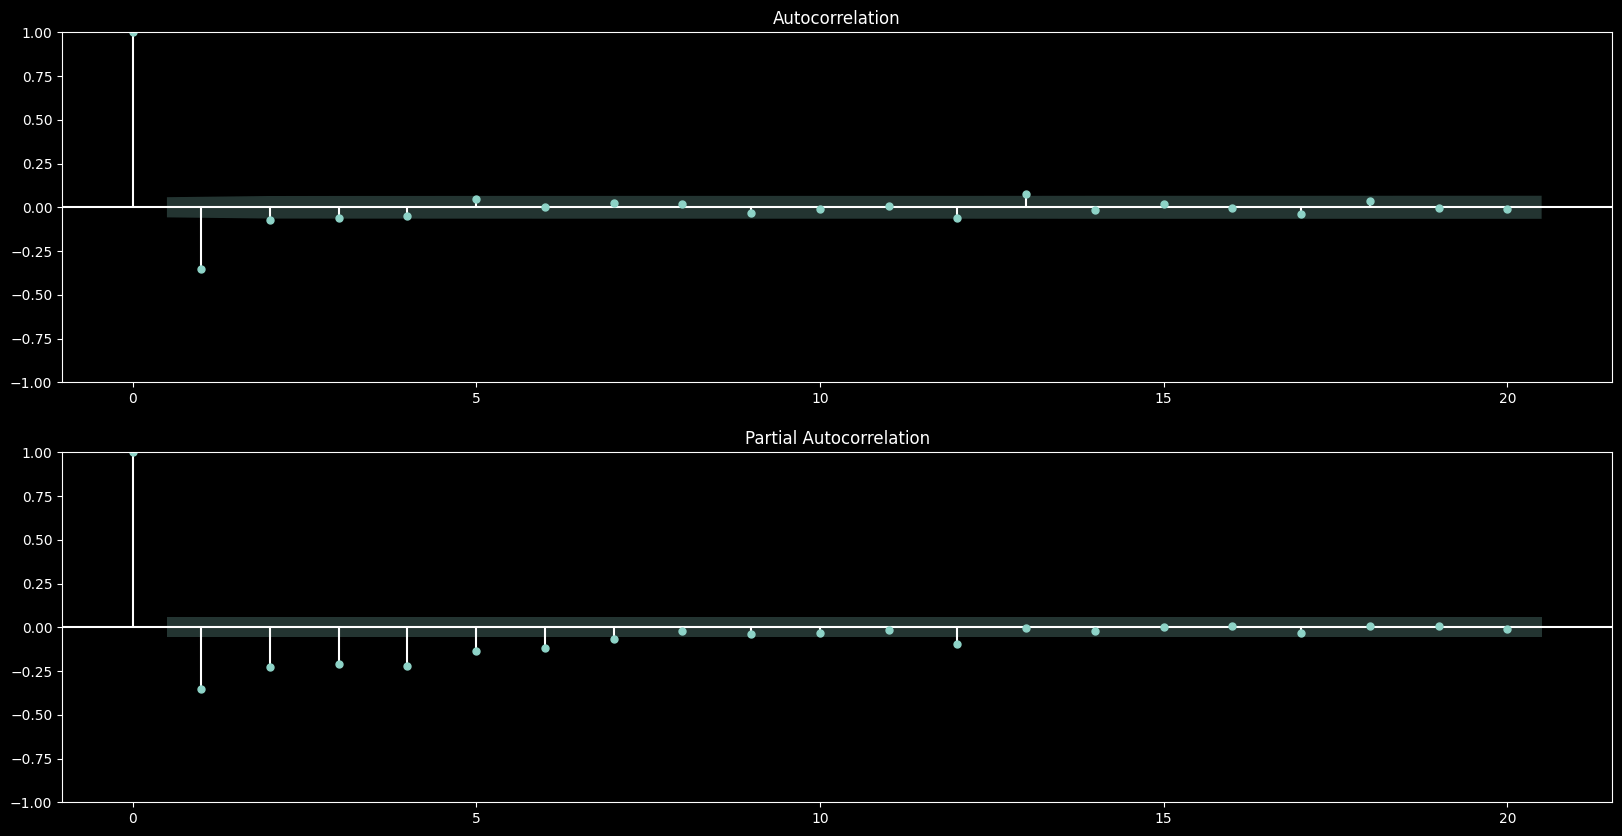

In [52]:
#차분
ts_diff = ts - ts.shift()
ts_diff = ts_diff.dropna()

plt.figure(figsize=(20,6))
plt.plot(ts_diff)
plt.title("Differenced Time Series")
plt.xlabel("Date")
plt.ylabel("Differenced Temperature")
plt.show()

#차분 후 ACF/PACF
fig = plt.figure(figsize=(20,10))

ax1 = fig.add_subplot(211)
sm.graphics.tsa.plot_acf(ts_diff, lags=20, ax=ax1)

ax2 = fig.add_subplot(212)
sm.graphics.tsa.plot_pacf(ts_diff, lags=20, ax=ax2)

plt.show()

비정상성을 제거하기 위해 1차 차분(First differencing) 을 수행한 결과이다.

차분된 시계열의 ACF와 PACF를 확인한 결과

ACF의 경우 lag 1에서 큰 음의 값이고, 이후 대부분 신뢰구간 안에 존재한다. 이는 MA(1) 구조의 특징이다.

PACF는 특정 lag에서 명확한 절단 없이 점진적으로 감소하는 것을 보아 AR 구조보다는 MA 구조에 가깝다는 것을 알 수 있다.

따라서 모형 선택은 차분 1회, MA(1) 형태, AR 성분 없으므로 d = 1, q = 1, p = 0, 즉 ARIMA(0,1,1)로 선정하였다

In [53]:
#ARIMA 모델 학습
model = ARIMA(ts, order=(0,1,1))
model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:               MeanTemp   No. Observations:                 1157
Model:                 ARIMA(0, 1, 1)   Log Likelihood               -1472.685
Date:                Tue, 10 Mar 2026   AIC                           2949.369
Time:                        20:41:46   BIC                           2959.475
Sample:                             0   HQIC                          2953.183
                               - 1157                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.7306      0.019    -38.705      0.000      -0.768      -0.694
sigma2         0.7478      0.023     32.883      0.000       0.703       0.792
Ljung-Box (L1) (Q):                  23.80   Jarque-

C:\Users\user\OneDrive\Desktop\힘\투빅스\정규세션 과제\PythonProject\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\OneDrive\Desktop\힘\투빅스\정규세션 과제\PythonProject\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\user\OneDrive\Desktop\힘\투빅스\정규세션 과제\PythonProject\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


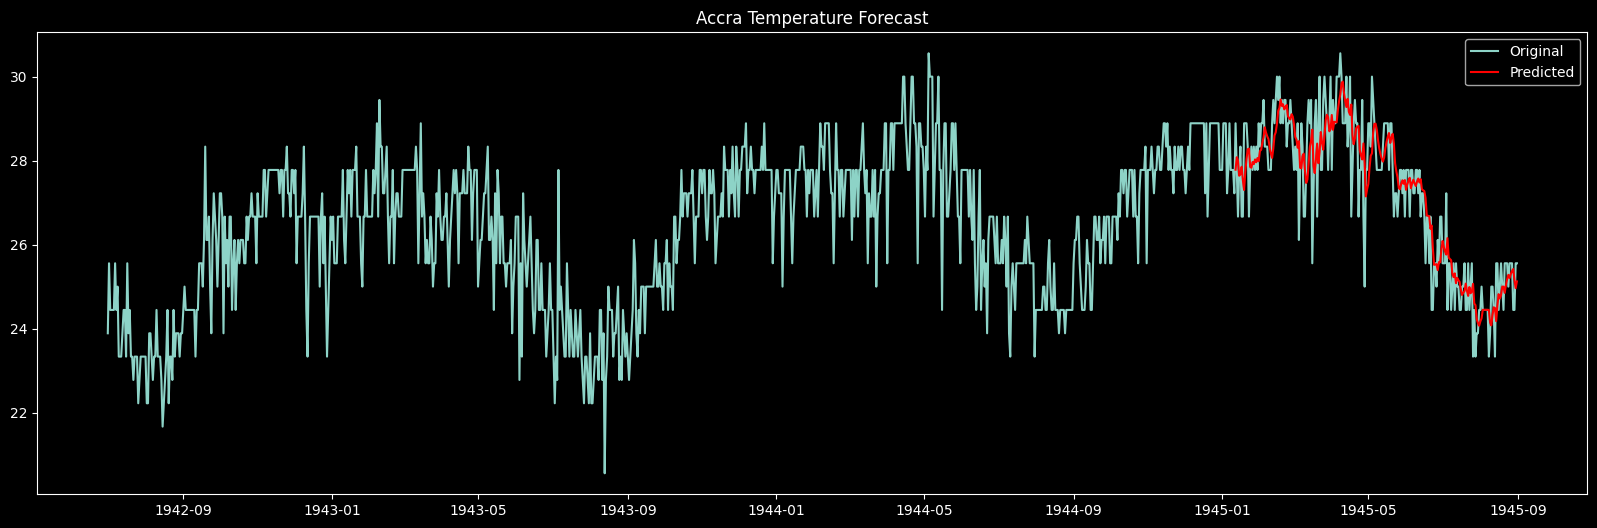

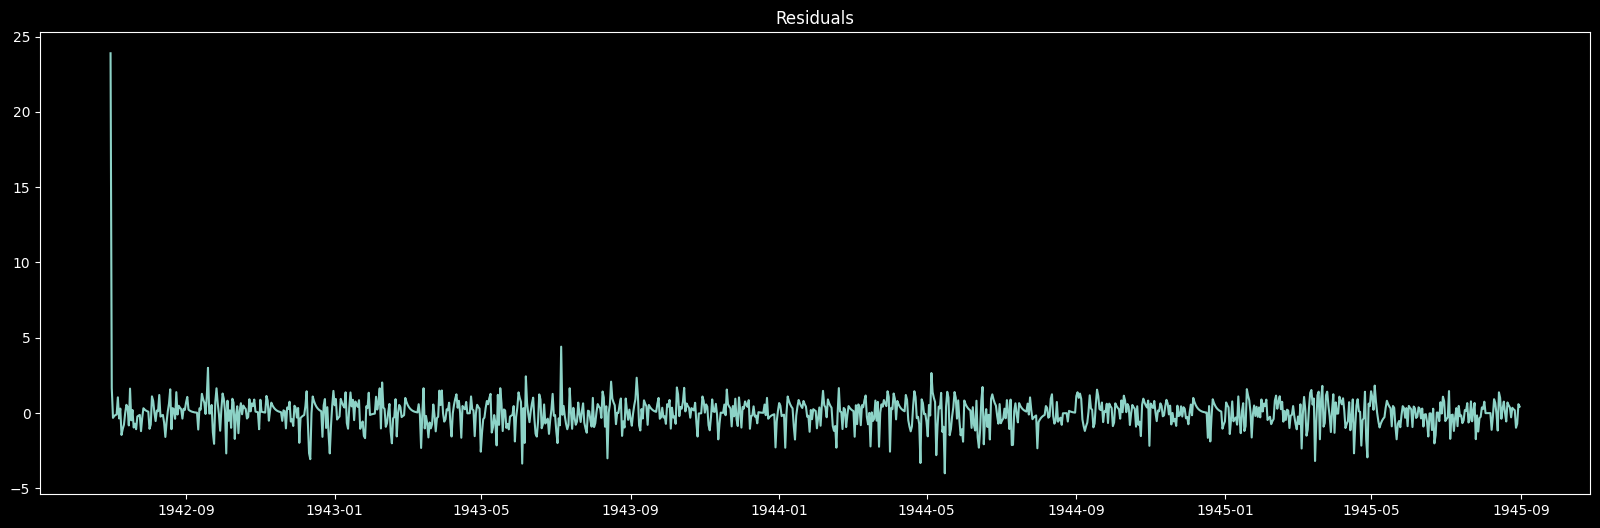

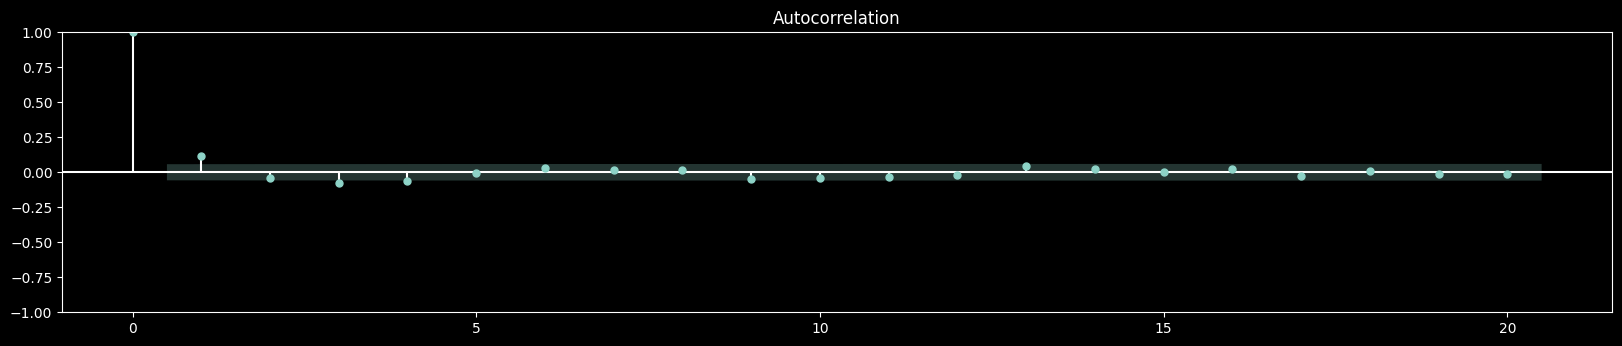

In [54]:
#예측
forecast = model_fit.predict(start=int(len(ts)*0.8), end=len(ts)-1)

plt.figure(figsize=(20,6))
plt.plot(ts, label="Original")
plt.plot(forecast, label="Predicted", color="red")
plt.title("Accra Temperature Forecast")
plt.legend()
plt.show()

#잔차 분석
resi = model_fit.resid

plt.figure(figsize=(20,6))
plt.plot(resi)
plt.title("Residuals")
plt.show()

#잔차 ACF
fig = plt.figure(figsize=(20,8))
ax1 = fig.add_subplot(211)
sm.graphics.tsa.plot_acf(resi, lags=20, ax=ax1)
plt.show()

ARIMA(0,1,1) 모델을 적용하여 시계열을 학습한 결과, 예측값은 전체적인 온도 변화 흐름을 비교적 잘 따라가는 모습을 보인다. 특히 잔차의 그래프를 보면, 평균이 0 근처이며 일정한 패턴이 없는 것으로 보아 모델이 대부분의 시계열 패턴을 설명했다는 의미로 해석할 수 있다.

잔차의 ACF 그래프에서는 대부분의 lag값이 신뢰구간 내에 분포하며, 뚜렷한 자기상관을 발견할 수 없기 때문에 잔차가 잡음의 성질을 가짐을 알 수 있다.

##

코드(특히 시각화)의 경우 AI의 도움을 일부 받았습니다...
실습 코드 수정하면서 하니까 안돌아가요... 시계열 넘모 어려워요... :(